In [ ]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))

import project.loader.load as load
from project.models_definitions import encoder
from project.models_definitions import decoder
from project.models_definitions.cvae import CVAE 

import matplotlib.pyplot as plt

import tensorflow as tf
from keras.callbacks import EarlyStopping

## parametros
dataset="fashion"
data = load.data(dataset=dataset)
x_train = data["x_train"]
x_val = data["x_val"]
y_train = data["y_train"]
y_val = data["y_val"]

original_dim = 28*28
beta = 1.0

train_dataset = tf.data.Dataset.from_tensor_slices(((x_train, y_train), x_train))
train_dataset = train_dataset.batch(128)

val_dataset = tf.data.Dataset.from_tensor_slices(((x_val, y_val), x_val))
val_dataset = val_dataset.batch(128)


intermediate_dim = [128,128,256,256,512,512,1024,784 ,1024]
latent_dim =      [2  ,64 ,64 ,128,128,256,256,784 ,512]


for i in range(len(intermediate_dim)):


    en = encoder.build_enconder(
        intermediate_dim=intermediate_dim[i],
        latent_dim=latent_dim[i],
    )
    de = decoder.build_decoder(
        intermediate_dim=intermediate_dim[i],
        latent_dim=latent_dim[i],
    )
    cvae_model = CVAE(
        encoder=en,
        decoder=de,
        original_dim=original_dim,
        beta=beta,
    )


    optimizer = tf.keras.optimizers.Adam()
    cvae_model.compile(optimizer=optimizer)


    cvae_model.total_loss_tracker.reset_state()
    cvae_model.reconstruction_loss_tracker.reset_state()
    cvae_model.kl_loss_tracker.reset_state()

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    history = cvae_model.fit(
        train_dataset,
        epochs=1000,
        batch_size=128,
        validation_data=val_dataset,
        callbacks=[early_stopping],
        verbose=1
    )

    en.save(f"en_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}.keras")
    de.save(f"de_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}.keras")


    plt.plot(history.history["loss"], label="total_loss")
    plt.plot(history.history["reconstruction_loss"], label="reconstruction_loss")
    plt.plot(history.history["kl_loss"], label="kl_loss")
    plt.xlabel("epochs")
    plt.ylabel("loss")
    plt.grid()
    plt.legend()
    #plt.savefig(f"loss_vs_epochs_model_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}")
    plt.show()

2025-12-17 17:10:47.252697: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-17 17:10:47.253490: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-17 17:10:47.258447: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-17 17:10:47.271341: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766002247.292460 1456062 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766002247.29

Usando fashion como dataset


2025-12-17 17:10:50.800897: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - kl_loss: 4.2189 - loss: 44.2569 - reconstruction_loss: 40.0478 - val_kl_loss: 3.4076 - val_loss: 30.4347 - val_reconstruction_loss: 27.1110
Epoch 2/1000
 41/430 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - kl_loss: 3.4621 - loss: 30.2062 - reconstruction_loss: 26.7441

KeyboardInterrupt: 

Varios modelos. Cambio de espacio latente

2025-12-19 03:00:50.224318: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-19 03:00:50.224732: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-19 03:00:50.227309: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-19 03:00:50.240221: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766124050.272922 2097046 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766124050.28

Usando fashion como dataset


2025-12-19 03:00:52.664423: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 2.1485 - loss: 63.6183 - reconstruction_loss: 61.4834 - val_kl_loss: 1.8649 - val_loss: 44.0783 - val_reconstruction_loss: 42.3294
Epoch 2/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 1.4359 - loss: 38.3037 - reconstruction_loss: 36.8701 - val_kl_loss: 1.1177 - val_loss: 34.6352 - val_reconstruction_loss: 33.5921
Epoch 3/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 1.2584 - loss: 31.5140 - reconstruction_loss: 30.2574 - val_kl_loss: 1.1374 - val_loss: 29.6938 - val_reconstruction_loss: 28.6126
Epoch 4/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 1.0600 - loss: 27.8731 - reconstruction_loss: 26.8139 - val_kl_loss: 1.0066 - val_loss: 26.8069 - val_reconstruction_loss: 25.8673
Epoch 5/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 1.0112 - loss: 25.5073 - reconstruction_loss: 24.4965 - val_kl_loss: 0.9320 - val_loss: 24.9107 - val_reconstruction_loss: 24.0398
Epoch 6/1000
430/430

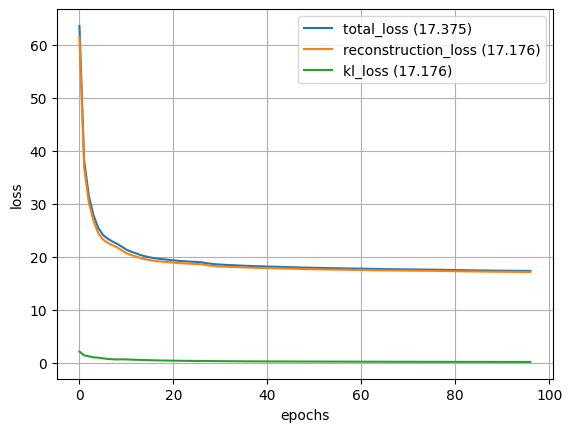

Epoch 1/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 1.9803 - loss: 60.4233 - reconstruction_loss: 58.4580 - val_kl_loss: 2.2079 - val_loss: 38.8744 - val_reconstruction_loss: 36.7332
Epoch 2/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 2.0280 - loss: 32.7071 - reconstruction_loss: 30.6820 - val_kl_loss: 1.6051 - val_loss: 29.1678 - val_reconstruction_loss: 27.5846
Epoch 3/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 1.4678 - loss: 26.6158 - reconstruction_loss: 25.1491 - val_kl_loss: 1.3510 - val_loss: 25.2542 - val_reconstruction_loss: 23.9205
Epoch 4/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 1.2536 - loss: 23.9104 - reconstruction_loss: 22.6572 - val_kl_loss: 1.1246 - val_loss: 23.7768 - val_reconstruction_loss: 22.6764
Epoch 5/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 1.0525 - loss: 22.6104 - reconstruction_loss: 21.5581 - val_kl_loss: 0.9700 - val_loss: 22.5574 - val_reconstruction_loss: 21.6141
Epoch 6/1000
430/430

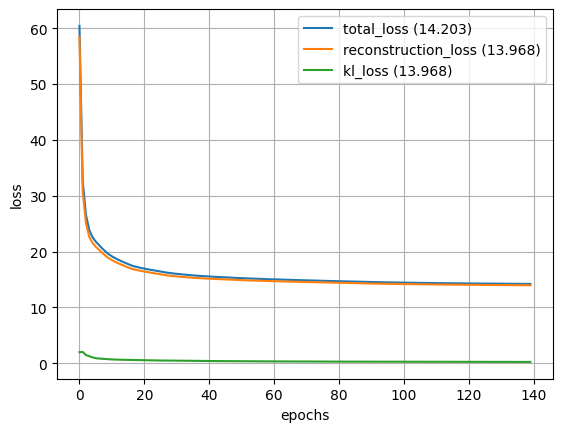

Epoch 1/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 1.5792 - loss: 59.4906 - reconstruction_loss: 57.9263 - val_kl_loss: 1.5946 - val_loss: 38.1246 - val_reconstruction_loss: 36.5630
Epoch 2/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 1.7929 - loss: 30.9605 - reconstruction_loss: 29.1705 - val_kl_loss: 1.5348 - val_loss: 27.0473 - val_reconstruction_loss: 25.5449
Epoch 3/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 1.3569 - loss: 24.9773 - reconstruction_loss: 23.6212 - val_kl_loss: 1.1518 - val_loss: 23.8945 - val_reconstruction_loss: 22.7805
Epoch 4/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 1.0822 - loss: 22.8732 - reconstruction_loss: 21.7913 - val_kl_loss: 0.9305 - val_loss: 22.5460 - val_reconstruction_loss: 21.6638
Epoch 5/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 0.9307 - loss: 21.7083 - reconstruction_loss: 20.7779 - val_kl_loss: 0.8760 - val_loss: 21.3302 - val_reconstruction_loss: 20.4947
Epoch 6/1000
430/430

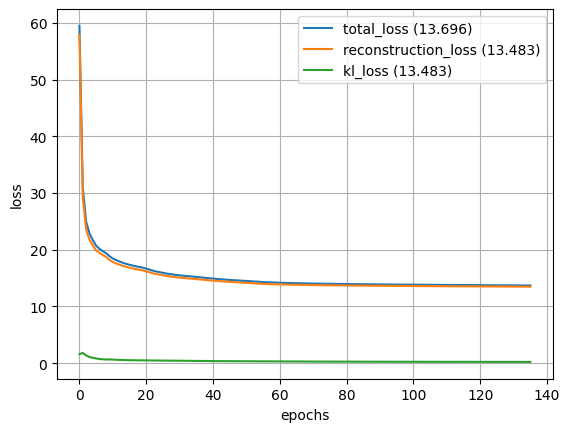

Epoch 1/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - kl_loss: 2.1021 - loss: 55.1931 - reconstruction_loss: 53.1045 - val_kl_loss: 1.9598 - val_loss: 35.5353 - val_reconstruction_loss: 33.6827
Epoch 2/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 1.8807 - loss: 28.9184 - reconstruction_loss: 27.0403 - val_kl_loss: 1.6532 - val_loss: 24.9889 - val_reconstruction_loss: 23.3718
Epoch 3/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 1.4236 - loss: 23.0900 - reconstruction_loss: 21.6668 - val_kl_loss: 1.2164 - val_loss: 22.1798 - val_reconstruction_loss: 20.9945
Epoch 4/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 1.0759 - loss: 21.2778 - reconstruction_loss: 20.2019 - val_kl_loss: 0.9589 - val_loss: 20.9918 - val_reconstruction_loss: 20.0636
Epoch 5/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 0.9129 - loss: 20.2331 - reconstruction_loss: 19.3203 - val_kl_loss: 0.8579 - val_loss: 20.0723 - val_reconstruction_loss: 19.2411
Epoch 6/1000
430/430

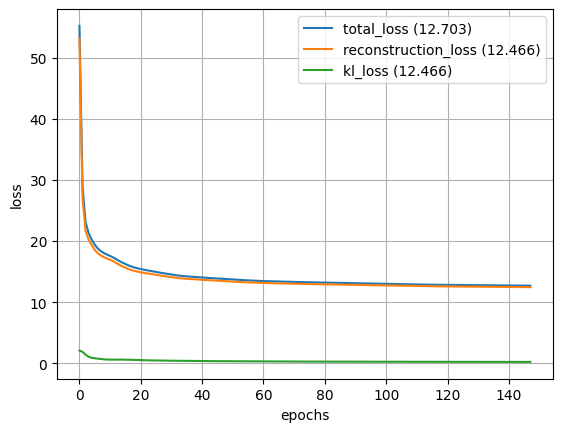

Epoch 1/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - kl_loss: 2.2987 - loss: 51.4493 - reconstruction_loss: 49.1638 - val_kl_loss: 2.0969 - val_loss: 32.3075 - val_reconstruction_loss: 30.2942
Epoch 2/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 2.0368 - loss: 26.3737 - reconstruction_loss: 24.3390 - val_kl_loss: 1.5988 - val_loss: 23.2114 - val_reconstruction_loss: 21.6420
Epoch 3/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 1.3396 - loss: 21.7885 - reconstruction_loss: 20.4494 - val_kl_loss: 1.1549 - val_loss: 21.0354 - val_reconstruction_loss: 19.8999
Epoch 4/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 1.0132 - loss: 20.2694 - reconstruction_loss: 19.2564 - val_kl_loss: 0.9085 - val_loss: 20.0181 - val_reconstruction_loss: 19.1249
Epoch 5/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 0.8559 - loss: 19.4292 - reconstruction_loss: 18.5733 - val_kl_loss: 0.8001 - val_loss: 19.3633 - val_reconstruction_loss: 18.5757
Epoch 6/1000
430/430

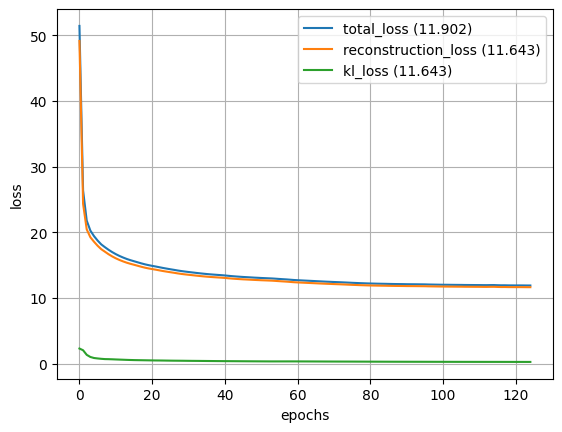

Epoch 1/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - kl_loss: 2.4635 - loss: 49.9166 - reconstruction_loss: 47.4660 - val_kl_loss: 2.0534 - val_loss: 31.1745 - val_reconstruction_loss: 29.1948
Epoch 2/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 1.7884 - loss: 25.9402 - reconstruction_loss: 24.1534 - val_kl_loss: 1.3974 - val_loss: 23.3257 - val_reconstruction_loss: 21.9567
Epoch 3/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 1.2166 - loss: 21.9277 - reconstruction_loss: 20.7115 - val_kl_loss: 1.0638 - val_loss: 21.1121 - val_reconstruction_loss: 20.0694
Epoch 4/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - kl_loss: 0.9790 - loss: 20.3046 - reconstruction_loss: 19.3257 - val_kl_loss: 0.9162 - val_loss: 19.9379 - val_reconstruction_loss: 19.0410
Epoch 5/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 0.8627 - loss: 19.1937 - reconstruction_loss: 18.3311 - val_kl_loss: 0.8291 - val_loss: 19.0280 - val_reconstruction_loss: 18.2077
Epoch 6/1000
430/430

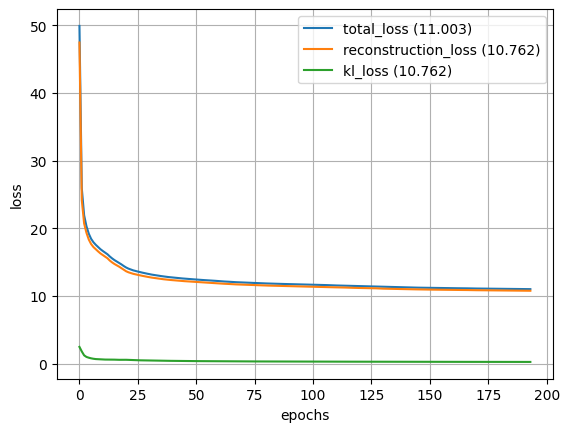

Epoch 1/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 2.5465 - loss: 47.6056 - reconstruction_loss: 45.0725 - val_kl_loss: 2.0932 - val_loss: 29.4538 - val_reconstruction_loss: 27.4096
Epoch 2/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 1.7632 - loss: 25.1179 - reconstruction_loss: 23.3565 - val_kl_loss: 1.5003 - val_loss: 22.5055 - val_reconstruction_loss: 21.0172
Epoch 3/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - kl_loss: 1.2523 - loss: 21.1984 - reconstruction_loss: 19.9465 - val_kl_loss: 1.1178 - val_loss: 20.5151 - val_reconstruction_loss: 19.4142
Epoch 4/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 0.9889 - loss: 19.6954 - reconstruction_loss: 18.7068 - val_kl_loss: 0.9260 - val_loss: 19.3156 - val_reconstruction_loss: 18.4046
Epoch 5/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 0.8656 - loss: 18.6927 - reconstruction_loss: 17.8274 - val_kl_loss: 0.8437 - val_loss: 18.4290 - val_reconstruction_loss: 17.5990
Epoch 6/1000
430/430

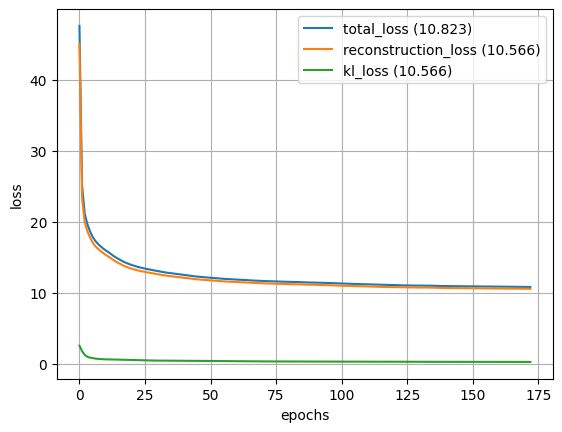

Epoch 1/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 2.2500 - loss: 47.5521 - reconstruction_loss: 45.3155 - val_kl_loss: 2.0535 - val_loss: 29.1594 - val_reconstruction_loss: 27.1573
Epoch 2/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 1.7467 - loss: 24.4756 - reconstruction_loss: 22.7303 - val_kl_loss: 1.4208 - val_loss: 22.1363 - val_reconstruction_loss: 20.7311
Epoch 3/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 1.2217 - loss: 20.8158 - reconstruction_loss: 19.5946 - val_kl_loss: 1.1071 - val_loss: 20.0417 - val_reconstruction_loss: 18.9483
Epoch 4/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 1.0033 - loss: 19.1905 - reconstruction_loss: 18.1874 - val_kl_loss: 0.9324 - val_loss: 18.8309 - val_reconstruction_loss: 17.9148
Epoch 5/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 0.8652 - loss: 18.2071 - reconstruction_loss: 17.3420 - val_kl_loss: 0.8132 - val_loss: 18.0203 - val_reconstruction_loss: 17.2204
Epoch 6/1000
430/430

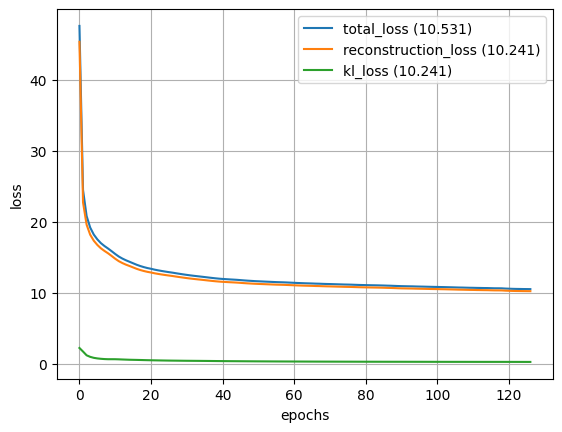

Epoch 1/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - kl_loss: 2.2151 - loss: 47.1898 - reconstruction_loss: 44.9883 - val_kl_loss: 1.9952 - val_loss: 28.4618 - val_reconstruction_loss: 26.5115
Epoch 2/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 1.6291 - loss: 24.1874 - reconstruction_loss: 22.5596 - val_kl_loss: 1.2940 - val_loss: 22.2345 - val_reconstruction_loss: 20.9642
Epoch 3/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 1.1486 - loss: 20.8098 - reconstruction_loss: 19.6616 - val_kl_loss: 1.0138 - val_loss: 20.0744 - val_reconstruction_loss: 19.0803
Epoch 4/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 0.9395 - loss: 19.2676 - reconstruction_loss: 18.3283 - val_kl_loss: 0.8832 - val_loss: 18.9686 - val_reconstruction_loss: 18.1002
Epoch 5/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 0.8232 - loss: 18.3261 - reconstruction_loss: 17.5031 - val_kl_loss: 0.7839 - val_loss: 18.1385 - val_reconstruction_loss: 17.3713
Epoch 6/1000
430/430

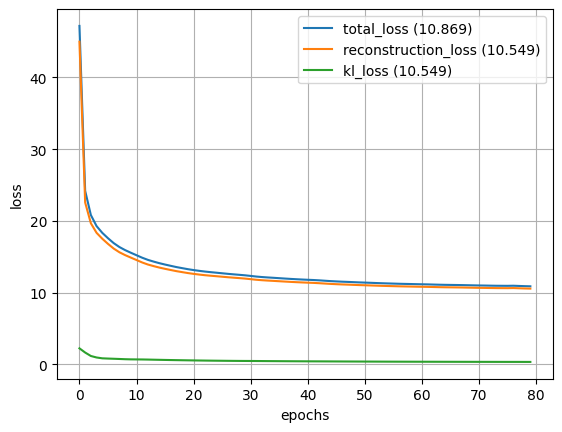

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))

import project.loader.load as load
from project.models_definitions import encoder
from project.models_definitions import decoder
from project.models_definitions.cvae import CVAE 

import matplotlib.pyplot as plt

import tensorflow as tf
from keras.callbacks import EarlyStopping

## parametros
dataset="fashion"
data = load.data(dataset=dataset)
x_train = data["x_train"]
x_val = data["x_val"]
y_train = data["y_train"]
y_val = data["y_val"]

original_dim = 28*28
beta = 1.0

train_dataset = tf.data.Dataset.from_tensor_slices(((x_train, y_train), x_train))
train_dataset = train_dataset.batch(128)

val_dataset = tf.data.Dataset.from_tensor_slices(((x_val, y_val), x_val))
val_dataset = val_dataset.batch(128)

lat = 128
intermediate_dim = [20,30,40,50 ,60 ,70 ,80 ,90 ,100]
latent_dim = [lat,lat,lat,lat,lat,lat,lat ,lat ,lat]


for i in range(len(intermediate_dim)):


    en = encoder.build_enconder(
        intermediate_dim=intermediate_dim[i],
        latent_dim=latent_dim[i],
    )
    de = decoder.build_decoder(
        intermediate_dim=intermediate_dim[i],
        latent_dim=latent_dim[i],
    )
    cvae_model = CVAE(
        encoder=en,
        decoder=de,
        original_dim=original_dim,
        beta=beta,
        name=f"cvae_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}"
    )


    optimizer = tf.keras.optimizers.Adam()
    cvae_model.compile(optimizer=optimizer)


    cvae_model.total_loss_tracker.reset_state()
    cvae_model.reconstruction_loss_tracker.reset_state()
    cvae_model.kl_loss_tracker.reset_state()

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    history = cvae_model.fit(
        train_dataset,
        epochs=1000,
        batch_size=128,
        validation_data=val_dataset,
        callbacks=[early_stopping],
        verbose=1
    )

    en.save(f"en_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}.keras")
    de.save(f"de_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}.keras")


    plt.plot(history.history["loss"], label=f"total_loss ({round(history.history["loss"][-1],3)})")
    plt.plot(history.history["reconstruction_loss"], label=f"reconstruction_loss ({round(history.history["reconstruction_loss"][-1],3)})")
    plt.plot(history.history["kl_loss"], label=f"kl_loss ({round(history.history["reconstruction_loss"][-1],3)})")
    plt.xlabel("epochs")
    plt.ylabel("loss")
    plt.grid()
    plt.legend()
    plt.savefig(f"loss_vs_epochs_model_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}")
    plt.show()

CROP-1 consta de 2 modelos entrenados por separados con imagnes limpias que interactuan entre sí con el fin de separa mezclas de imagenes. Por un lado un autoeoncder variacional condicional (CVAE) cuyo objetivo es reconstruir una imagen a partir de una imagen de input y dos condiciones (en general son iguales) y una red convolucional capaz de aprender representaciones para clasificar las imagenes. 


## Auto Encoder

### Encoder
Los autoencoder son redes neuronales de tipo Enconder-Decoder con el fin de generar output igual al input. 
Los Encoders comprimen las imagenes en varios pasos hasta alcanzar una representación en el espacion latente. 
En este caso, la imagen input se apalana y se concatena con las condición del encoder (input_concat) que se pasa a una capa densa de dimensión "intermediate_dim" (por defecto 128) y luego se pasa por otra capa densa cuya salida es de dimensión laten_dim (por defecto 2).

### Decoder
Los Decoders generan un output a partir del espacio latente usando "descomprimendo" el output en dimensiones cada vez mayores hasta alcanzar un resultado de una dimensión igual a la del input. En este caso, la entrada del decoder es el espacio latente, generado por el encoder, concatenado con la condición del decoder. Este decoder_input, es usado en una capa densa cuya salida es un vector de dimesión "intermediate_dim" (igual que en el encoder) y finalmente la salida del decoder es una vector de dimensión igual a la de entrada (28*28).

## Auto Encoder Variacional
A diferencia el los autoencoders, los autoencoder variacionales tienen como obejtivo aprender representaciones y generar pequeñas variaciones las entradas. Esto se logra usando una estructura clásica de encoder-decoder pero remplazando el espacio latente por una representación probabilistica. 
De esa manera. El enconder logra mapear el espacio de los inputs a distribuciones en el espacio latente y el decoder mapea esas distribuciones nuevamente al espacio de entrada. 
Para entrenar estos modelos, es necesario introducir dos metricas de error. Por una lado tenemos el error de reconstrucción que mide la calidad de los outputs generados contra los inputs. Por otro lado tenemos la divergencia Kullback–Leibler que mide la diferencia entre la distribución de la represensión de los datos en el espacio latente y una gaussiana. La función de coste es la suma de estos dos errores. Adicionlamente, el coste KL se multiplica por un factor Beta(en nuestro caso 1).
En estas arquitecturas para poder seguir usando backpropagation como método de ajuste de pesos, es necesario hacer un muestro del espacio latente, por lo que ademas del espacio latente z tenemos z_mu y z_var. //entender para que se usan


# Auto Encoder Variacional Condicional (CVAE)
Un auto Encoder Variacional Condicional es VAE al que se le agrega un vector de condiciones para controlar el output generado, un promt. El espacio latente ahora no necesita aprender clases, parende estrucutras como formas ne lugar de clases. Cualquier punto del espacio latente puede ser usando para generar cualquier imagen dada la condción del decoder.


## Resumen de parametros destacados:
- Dimensión del espacio latente: 2 (por defecto, se puede elegir) 
- Dimensión intermedia: 128 (por defecto)
- Beta 1
- Dimensión de entrada, 28*28
- 10 clases en el data set --> Vector de condiciones de 10.


## Predictor
El predictor o clasificador es una red neuronal convolucional con el fin de aprender representaciones de las distitnas clases.
## Parametros de interes:
Función de activacion softmax para que el output sea una probabilidad
batchnormalization (buscar)
dropout de 0.5 (buscar)



### Modelo CROP-1:

El modelo funciona con la interacción de los otros modelos explicados anteriormente con el fin de, dada una imagen mezcla, obtener las dos imagenes limpias.


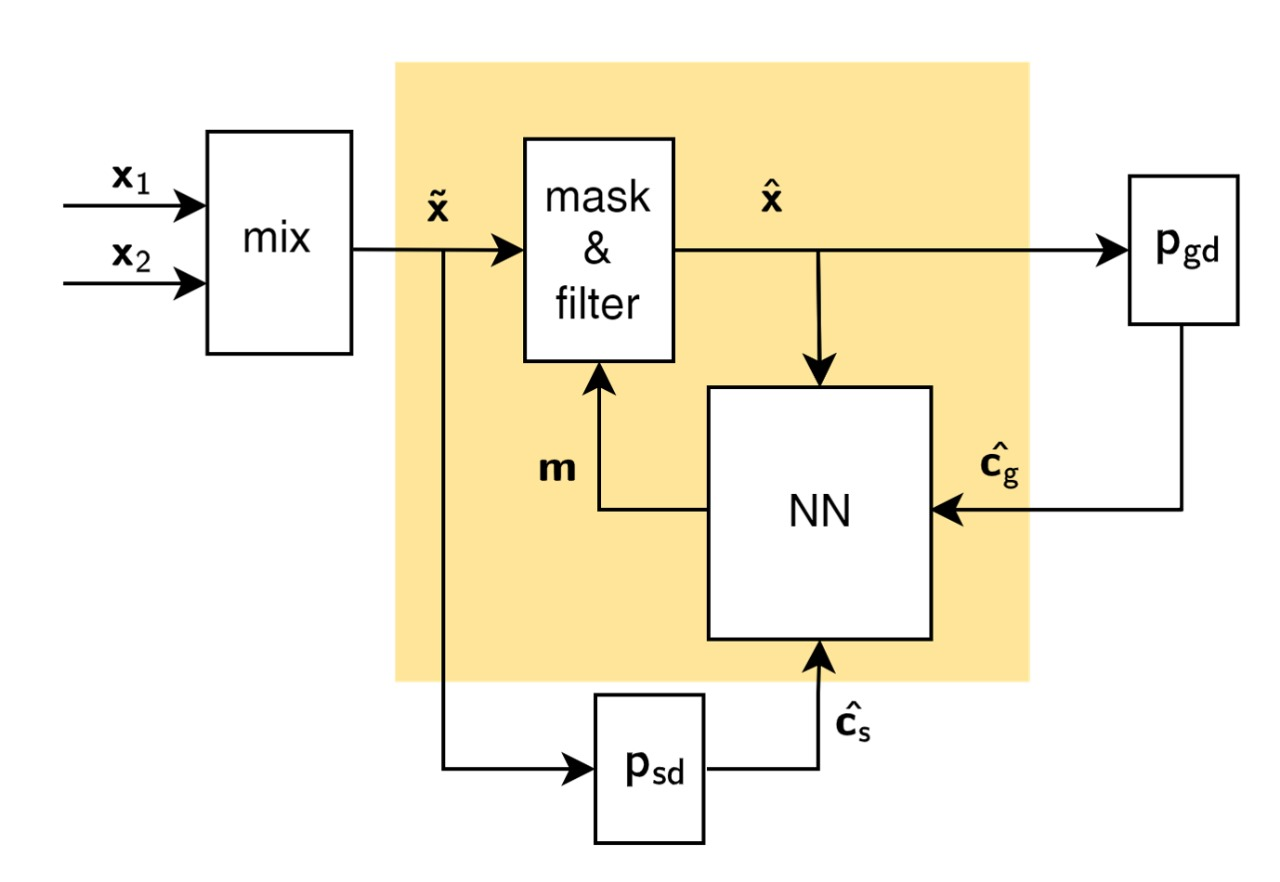

En un primer instante, la imagen mezcla $ x^~ $ es alimentada a Psd (modelo predictor) para geenrar la condición que es input del CVAE Cs. a su vez la imagen muestra se procesa con mascaras y/o filtros (en la primera pasada no hay ni mascaras ni filtros, la imagen pasa limpia) x ^. Esta imagen, junto con la condición alimentan a la CVAE el cual genera una imagen del dígito predicho (el indicado por Cs) la cual se usa como mascara de para la próxima iteración. 
Durante las siguientes iteraciones la estimación del digito más probable queda a cargo del bloque Pgd qeu genera la condición Cg la cual alimenta el CVAE. Mientras tanto la salida m de la iteración i-1 se usa como máscara para la salida de la iteración i para genera x^, lo cual vuelve a arrancar el ciclo. 

